In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import matplotlib.pyplot as plt
import yaml

import wespeaker
from wespeaker.diar.plot_diar import plot_diarization
from wespeaker.utils.meeting_sim.room import (
    RoomConfig, ArrayConfig, MeetingRoom, create_room, compute_rirs, beamform, plot_room_topdown
)

2026-05-06 13:54:39.100918: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
/work/user_data/danwells/.local/lib/python3.10/site-packages/s3prl/upstream/byol_s/byol_a/common.py:20: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("sox_io")
ESPnet is not installed, cannot use espnet_hubert upstream


In [34]:
room_cfg = RoomConfig(length=4.0, width=3.0, height=2.4, rt60=0.4)
array_cfg = ArrayConfig(n_mics=8, spacing=0.04)
meeting_room = create_room(room_cfg, array_cfg, n_speakers=3,)
                           #configured_positions=[[1.5, 1.0, 1.5],
                           #                      [2.5, 1.0, 1.5],
                           #                      [2.0, 3.0, 1.5]])

In [5]:
meeting_room.speaker_positions

[array([1. , 1.5, 1.5]), array([1. , 2.5, 1.5]), array([4. , 2. , 1.5])]

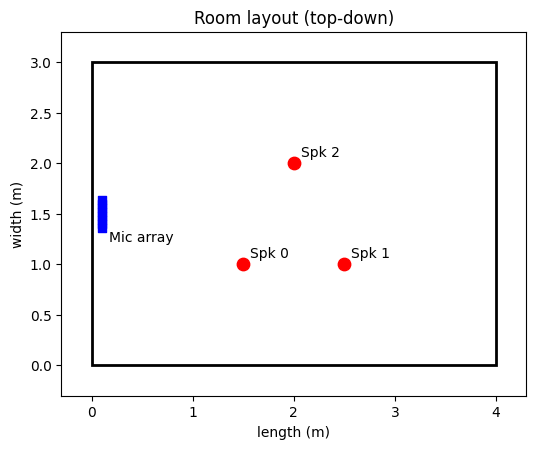

In [35]:
_ = plot_room_topdown(meeting_room)

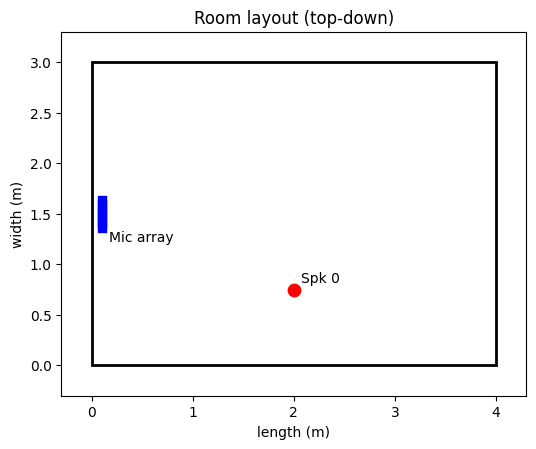

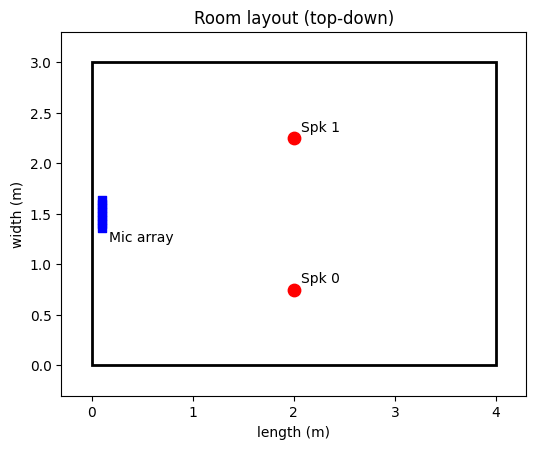

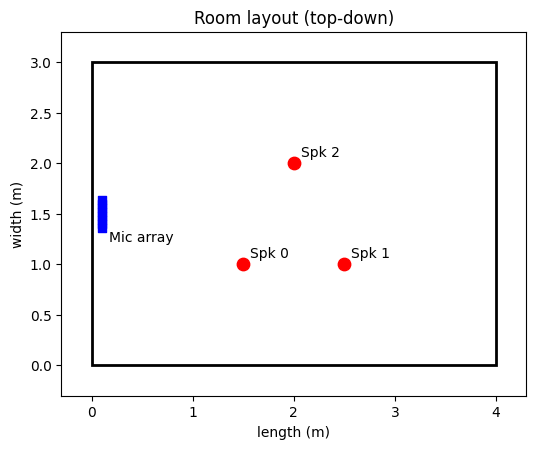

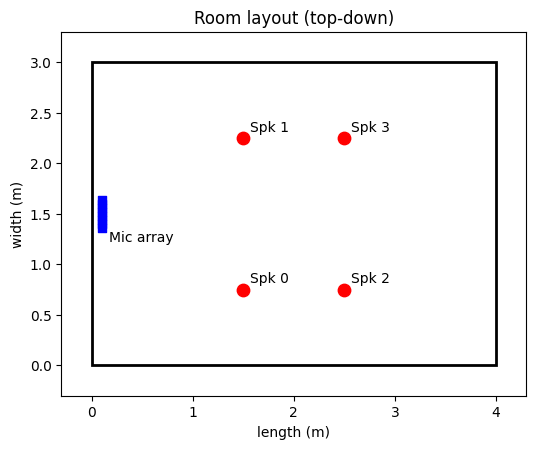

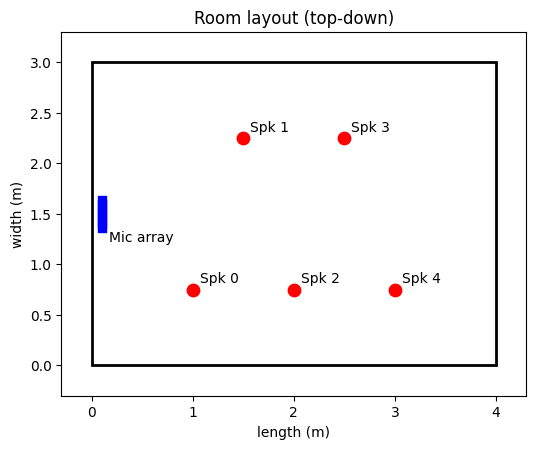

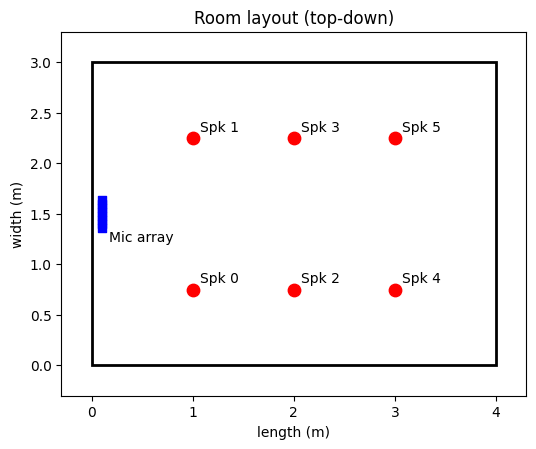

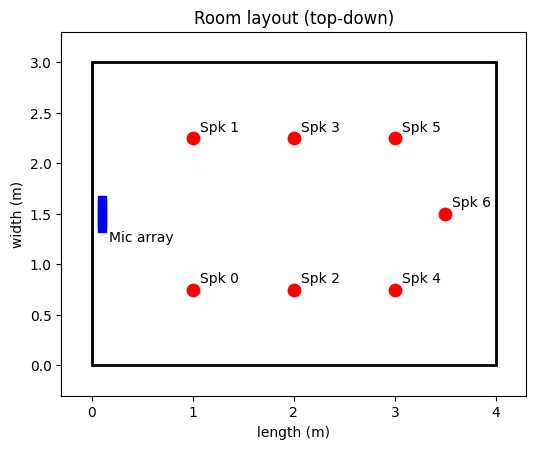

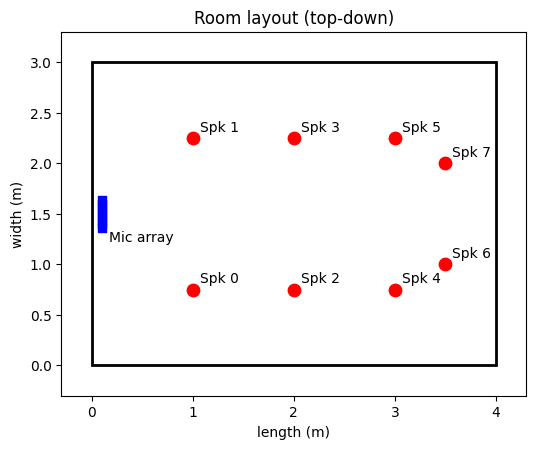

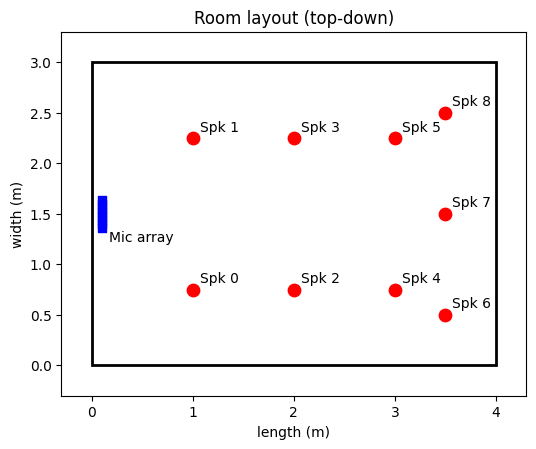

In [41]:
for i in range(1, 10):
    room = create_room(room_cfg, array_cfg, n_speakers=i)
    plot_room_topdown(room)

In [3]:
help(plot_diarization)

Help on function plot_diarization in module wespeaker.diar.plot_diar:

plot_diarization(hyp_rttm, ref_rttm=None, wav_path=None, enrol_scp=None, emb_scp=None, utt_id=None, start_time=None, end_time=None, monochrome=False, figsize=None, ax=None)
    Plot diarization results with optional reference comparison.
    
    Displays each speaker on a horizontal track with time on the x-axis.
    If both ref_rttm and hyp_rttm are provided, maps hypothesis speakers
    to reference speakers and shows both as offset bars within each track.
    
    Speaker mapping strategy:
      - If both enrol_scp and emb_scp are provided, uses embedding-based
        cosine similarity matching against enrolled speaker embeddings.
      - Otherwise (default when ref_rttm is given), uses temporal overlap
        with the Hungarian algorithm.
    
    Args:
      hyp_rttm: Path to the hypothesis RTTM file.
      ref_rttm: Optional path to the reference RTTM file.
      wav_path: Optional path to audio file for RM

(<Figure size 1200x380 with 2 Axes>,
 array([<Axes: ylabel='RMS'>, <Axes: xlabel='Time (s)'>], dtype=object))

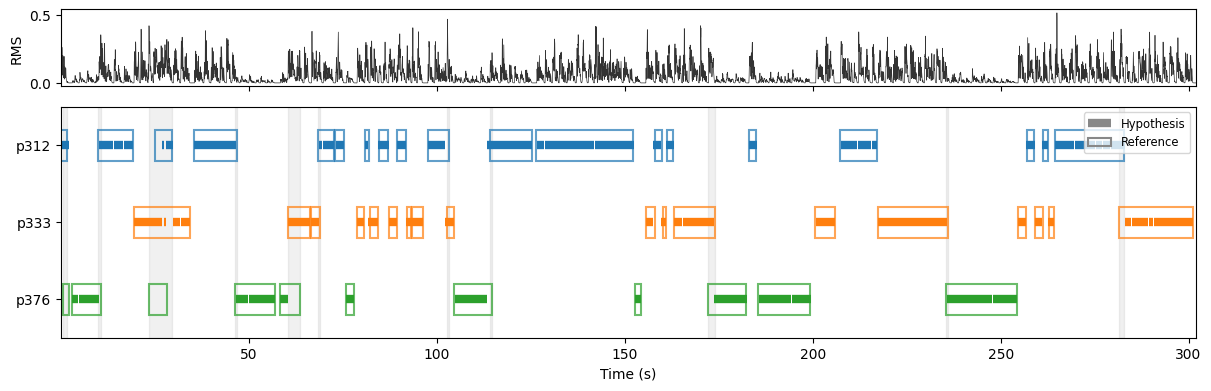

In [5]:
vctk_dir = '/work/user_data/danwells/wespeaker/data-files/vctk/meeting-sim'
exp_dir = f'{vctk_dir}/exp/win_1.5_stride_0.5_system_sad'

meeting_id = 'meeting_0008'

plot_diarization(
    hyp_rttm=f'{exp_dir}/spectral_cluster/system_sad_rttm',
    ref_rttm=f'{vctk_dir}/all_meetings.rttm',
    utt_id=meeting_id,
    wav_path=f'{vctk_dir}/meetings/{meeting_id}/mixed.wav',
    #start_time=0, end_time=90,
    show_overlap=True, monochrome=False,
    ref_style='hollow', # field, hollow, line
)

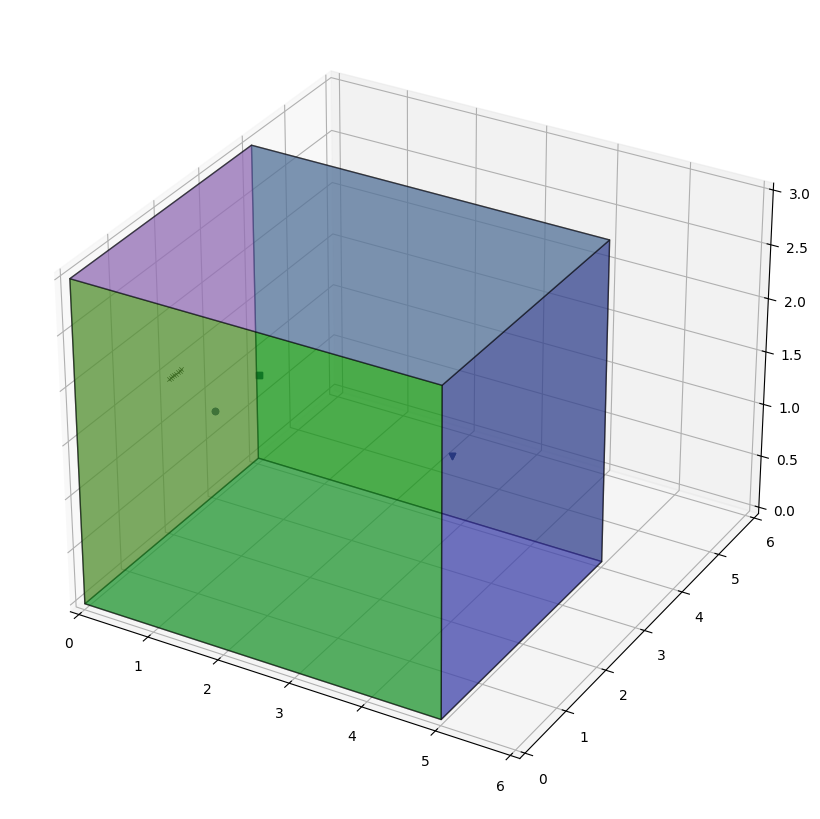

In [10]:
# 2d plot of 3d room
fig, ax = meeting_room.room.plot(
    img_order=0,
    figsize=(10, 8)
)

ax.set_xlim([0, 6])
ax.set_ylim([0, 6])
plt.show()